### Basic Chatbot with Langgraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
# from langchain.chat_models import init_chat_model

llm = ChatGroq(model= "llama3-8b-8192")
# llm = init_chat_model("groq:llama3-8b-8192")

In [5]:
# Node 
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmChatbot", chatbot)

graph_builder.add_edge(START, "llmChatbot")
graph_builder.add_edge("llmChatbot", END)

graph = graph_builder.compile()

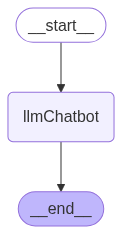

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
response = graph.invoke({"messages": "Hi"})

In [9]:
response["messages"]
# response["messages"][-1].content

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='6980c09d-1626-4ee4-8ea6-cda75fc9665b'),
 AIMessage(content="Hi! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 11, 'total_tokens': 36, 'completion_time': 0.026878157, 'prompt_time': 0.002116471, 'queue_time': 0.044838629, 'total_time': 0.028994628}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_24ec19897b', 'finish_reason': 'stop', 'logprobs': None}, id='run--a0c8666e-1c79-4c94-8e37-f98676b85e97-0', usage_metadata={'input_tokens': 11, 'output_tokens': 25, 'total_tokens': 36})]

In [10]:
for event in graph.stream({"messages": "Hi, how are you?"}):
    # print(event)
    for value in event.values():
        print(value["messages"])


[AIMessage(content="I'm just a language model, I don't have feelings like humans do, but I'm functioning properly and ready to help you with any questions or tasks you have! How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 16, 'total_tokens': 58, 'completion_time': 0.045013155, 'prompt_time': 0.002800531, 'queue_time': 0.044425462, 'total_time': 0.047813686}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_24ec19897b', 'finish_reason': 'stop', 'logprobs': None}, id='run--40931990-aed1-4bd6-8c0f-177f9fd1d7eb-0', usage_metadata={'input_tokens': 16, 'output_tokens': 42, 'total_tokens': 58})]


In [11]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
# tool.invoke("Friedrich Nietszche")

In [12]:
def multiply(a: float, b: float) -> float:
    """Multiply a and b

    Args:
        a (float): First number
        b (float): Second number

    Returns;
        (float): Returns a * b
    """
    return a * b

def add(a: float, b: float) -> float:
    """Add a and b

    Args:
        a (float): First number
        b (float): Second number

    Returns:
        (float): Returns a + b
    """
    return a + b

In [13]:
tools = [tool, add, multiply]
llmWithTools = llm.bind_tools(tools)

In [14]:
# llm
llmWithTools

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x72789c533470>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72789c58db20>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domai

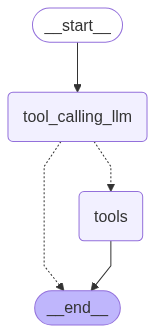

In [15]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

def tool_calling_llm(state: State):
    return {"messages": [llmWithTools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
response = graph.invoke({"messages": "What is the recent ai news and then multiply 5 by 2"})
#response
#response["messages"][-1].content
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the recent ai news and then multiply 5 by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (e60s462bb)
 Call ID: e60s462bb
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: day
  multiply (t1xhmmmbp)
 Call ID: t1xhmmmbp
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/@CherryZhouTech/ai-news-july-5-11-2025-the-10-biggest-ai-developments-this-week-a0c2445c6479", "title": "AI News | July 5–11, 2025: The 10 Biggest AI Developments This ...", "content": "## 1. Kling AI Launches Ketu 2.1: Major Leap in Image Generation\n\nKling AI unveiled its next-gen image generation model, Ketu 2.1 on July 11, marking signific

### ReAct Agent

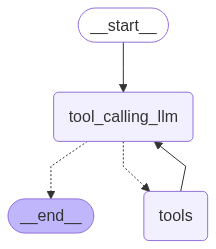

In [17]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

def tool_calling_llm(state: State):
    return {"messages": [llmWithTools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response = graph.invoke({"messages": "What is the recent ai news and then multiply 5 by 2"})
# response
# response["messages"][-1].content
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the recent ai news and then multiply 5 by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (qkzezjrer)
 Call ID: qkzezjrer
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: day
    topic: news
  multiply (2bbtq8yp7)
 Call ID: 2bbtq8yp7
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2025/07/11/humanoids-avs-and-whats-next-in-ai-hardware-at-techcrunch-disrupt-2025/", "title": "Humanoids, AVs, and what's next in AI hardware at Disrupt 2025", "content": "They will unpack how it's enabling new applications across humanoid robotics and autonomous vehicles. Expect deep technical insight, and a look at what it

### ReAct Agent with Memory

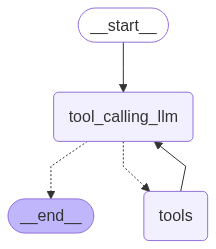

In [19]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

memory = MemorySaver()

def tool_calling_llm(state: State):
    return {"messages": [llmWithTools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile(checkpointer = memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
# THREAD_ID should be UNIQUE
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages" : "I am working on Agentic AI"}, config = config)
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

I am working on Agentic AI
================================== Ai Message ==================================

I'm happy to help you with that. Can you provide more context or details about the specific task or problem you're trying to solve with Agentic AI? This will help me better understand your needs and provide more accurate guidance.


In [21]:
# THREAD_ID should be UNIQUE
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages" : "What am I working on?"}, config = config)
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

I am working on Agentic AI
================================== Ai Message ==================================

I'm happy to help you with that. Can you provide more context or details about the specific task or problem you're trying to solve with Agentic AI? This will help me better understand your needs and provide more accurate guidance.
================================ Human Message =================================

What am I working on?
================================== Ai Message ==================================

You are working on implementing a conversation flow using the provided tool definitions and instructions. You need to generate a JSON string that matches the specified structure and schema, which will be used to call a tool or tools to answer a user's question.


### Stream Modes
stream() and astream_events()

### Stream Method

In [22]:
# Stream_Mode: updates - Appends messages, Streams updates to the state of graph after each node call
# for chunk in graph.stream({"messages": "Tell me the recent advances in AI and multiply 2 * 3"}, config = config, stream_mode = "updates"):
    # print(message)
# Stream_Mode: values - Prints all messages, Streams complete state of graph after each node call
for message in graph.stream({"messages": "Tell me the recent advances in AI and multiply 2 * 3"}, config = config, stream_mode = "values"):
    print(message)
# for message in response["messages"]:
    # message.pretty_print()

{'messages': [HumanMessage(content='I am working on Agentic AI', additional_kwargs={}, response_metadata={}, id='4754808a-2027-4d50-9d23-bb17d6734f61'), AIMessage(content="I'm happy to help you with that. Can you provide more context or details about the specific task or problem you're trying to solve with Agentic AI? This will help me better understand your needs and provide more accurate guidance.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 2390, 'total_tokens': 2437, 'completion_time': 0.051084951, 'prompt_time': 0.349979584, 'queue_time': 0.05073532399999997, 'total_time': 0.401064535}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_24ec19897b', 'finish_reason': 'stop', 'logprobs': None}, id='run--0e1c98dc-4c04-4de5-96f2-ada608849a9b-0', usage_metadata={'input_tokens': 2390, 'output_tokens': 47, 'total_tokens': 2437}), HumanMessage(content='What am I working on?', additional_kwargs={}, response_metadata={}, id='2b8

### AStream Method

In [24]:
config = {"configurable": {"thread_id": "2"}}

async for event in graph.astream_events({"messages": "Hello how are you?"}, config, version = "v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hello how are you?'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '8b12007d-5b8d-404b-873f-784a932cd7a6', 'metadata': {'thread_id': '2'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='I like playing guitar', additional_kwargs={}, response_metadata={}, id='f4541ae0-b267-474f-ac3d-63c129706e60'), AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'yq3zm1m8c', 'function': {'arguments': '{"query":"best guitar solo","search_depth":"advanced","time_range":"year","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_24ec19897b'}, id='run--bbc12f09-4679-41ac-bcd8-3db529150539', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'best guitar solo', 'search_depth': 'advanced', 'time_range': 'year', 'topic': 'general'}, 'id': 'yq3zm1m